In [1]:
# Import necessary libraries

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
# Import preprocessed data as a pandas dataframe

talents = pd.read_csv("potential_talent_eda_output.csv")
talents.head()

,id,job_title,location,connection_num,frequency,job_title_word_count,keyword_match_score,has_aspiring,has_seeking,location_word_count,has_texas,has_california,has_new_york,seniority_score
0,1,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",85,7,15,2,1,0,2,1,0,0,1
1,2,Native English Teacher at EPIK (English Progra...,Kanada,500,5,9,0,0,0,1,0,0,0,1
2,3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,6,4,2,1,0,4,0,0,0,1
3,4,People Development Coordinator at Ryan,"Denton, Texas",500,6,5,1,0,0,2,1,0,0,2
4,5,Advisory Board Member at Celal Bayar University,"İzmir, Türkiye",500,4,7,0,0,0,2,0,0,0,1


In [3]:
# Use TF-IDF to rank candidates according to multiple keywords (queries)

queries = ["Aspiring human resources", "seeking human resources"]

In [4]:
# Combine text columns

talents["combined_text"] = talents["job_title"] + " " + talents["location"]

corpus = talents["combined_text"].tolist() + queries

In [5]:
# TF-IDF vectorizer

vectorizer = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=1)

tfidf_matrix = vectorizer.fit_transform(corpus)

In [6]:
candidate_matrix = tfidf_matrix[:len(talents)]
query_matrix = tfidf_matrix[len(talents):]

sim_matrix = cosine_similarity(candidate_matrix, query_matrix)

In [7]:
# Average similarity across role queries
talents["multi_query_tfidf_score"] = sim_matrix.mean(axis=1)

In [8]:
# Heuristic model that includes seniority level and number of connections

heuristic_fit = talents["multi_query_tfidf_score"] + 0.01 * (talents["seniority_score"]) + 0.01 * (talents["connection_num"] >= 300).astype(int)
talents["base_score"] = heuristic_fit

In [9]:
ranked_talents = talents.sort_values("base_score", ascending=False)
ranked_talents[["id", "job_title", "base_score"]].head(10)

,id,job_title,base_score
21,73,"Aspiring Human Resources Manager, seeking inte...",0.386640
13,28,Seeking Human Resources Opportunities,0.308072
12,27,Aspiring Human Resources Management student se...,0.271890
45,97,Aspiring Human Resources Professional,0.259416
48,100,Aspiring Human Resources Manager | Graduating ...,0.256554
8,10,Seeking Human Resources HRIS and Generalist Po...,0.252171
47,99,Seeking Human Resources Position,0.241424
5,6,Aspiring Human Resources Specialist,0.238063
2,3,Aspiring Human Resources Professional,0.232338
6,7,Student at Humber College and Aspiring Human R...,0.229498


In [10]:
# Re-rank candidates when a candidate is starred 

starred_index = 20

X = vectorizer.fit_transform(talents["combined_text"])

starred_vector = X[starred_index]
sim_scores = cosine_similarity(X, starred_vector).ravel()

talents["star_similarity_score"] = sim_scores

In [11]:
# Revise scoring model using the starred candidate profile

# Create weightage factor alpha
alpha = 0.5

talents["new_score"] = (1 - alpha) * talents["base_score"] + alpha * talents["star_similarity_score"]

In [12]:
reranked_talents = talents.sort_values("new_score", ascending=False).reset_index()
reranked_talents[["id", "job_title", "new_score"]].head(10)

,id,job_title,new_score
0,72,Business Management Major and Aspiring Human R...,0.610365
1,73,"Aspiring Human Resources Manager, seeking inte...",0.316284
2,79,Liberal Arts Major. Aspiring Human Resources A...,0.254784
3,27,Aspiring Human Resources Management student se...,0.214141
4,88,Human Resources Management Major,0.211079
5,100,Aspiring Human Resources Manager | Graduating ...,0.202476
6,97,Aspiring Human Resources Professional,0.193837
7,66,Experienced Retail Manager and aspiring Human ...,0.184843
8,28,Seeking Human Resources Opportunities,0.175376
9,6,Aspiring Human Resources Specialist,0.175178


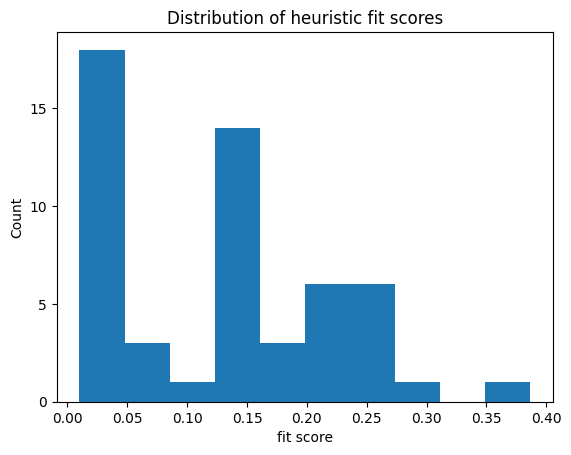

In [13]:
# Plot heuristic fit score histogram

plt.figure()
plt.title("Distribution of heuristic fit scores")
plt.hist(talents["base_score"], bins=10)
plt.xlabel("fit score")
plt.ylabel("Count")
plt.yticks(np.arange(0,20,5))
plt.show()

Based on this distribution, a suitable cut-off can be determined (e.g. 0.20) to select only the top candidates

### Challenges

__We are interested in a robust algorithm, tell us how your solution works and show us how your ranking gets better with each starring action.__

Since the target variable is not available, I treat the problem as an unsupervised ranking task. I first rank candidates based on TF-IDF similarity to the role query, then enhance this with keyword-based and metadata features. When a recruiter stars a candidate, I use that as relevance feedback and re-rank candidates based on similarity to the starred profile. Each starring action makes the ranking more aligned with recruiter intent, effectively turning the system into a feedback-driven ranking engine.

__How can we filter out candidates which in the first place should not be in this list?__

Without the target variable, I use a conservative filter based on text similarity and engineered features of candidate profiles. My model calculates a score indicating the degree of candidate's fit for the target roles. Using a suitable cut-off, I can retain only the relevant candidates.

__Can we determine a cut-off point that would work for other roles without losing high potential candidates?__

There are two ways to select a cut-off:
1. Select a certain % of top candidates (e.g. top 20%) using the predicted score. This strategy ensures that only top candidates are selected.
2. Select a cut-off based on experience. This strategy is subject to human bias and can be unreliable at times.

__Do you have any ideas that we should explore so that we can even automate this procedure to prevent human bias?__

To limit human bias, I combine star-based re-ranking with a stable base ranking so that no single feedback signal dominates.